Ethiopia Food Prices — 07 ARIMA & SARIMA MODELING


Part 1: Non-Seasonal ARIMA ($p, d, q$)Step 1.1: Choose Candidate Parameters & Train ARIMABased on our stationarity testing in Notebook 05, our differencing parameter is fixed at $d = 1$. We use an initial candidate configuration of ARIMA(1, 1, 1) to capture short-term momentum.

In [16]:
import warnings

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load data and recreate series y (from Notebook 05)
df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])

market_focus = 'Addis Ababa'
commodity_focus = 'Maize (white)'
unit_focus = '100 KG'

series_df = df[
    (df['market'] == market_focus)
    & (df['commodity'] == commodity_focus)
    & (df['pricetype'] == 'Wholesale')
    & (df['unit'] == unit_focus)
].copy()

series_df = series_df.sort_values('date').set_index('date')
y = series_df['usdprice'].resample('MS').mean().interpolate(method='linear')

# 2. Chronological Train/Test Split (from Notebook 06)
test_size = 24
train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print('Data loaded and train/test splits ready for ARIMA modeling!')

Data loaded and train/test splits ready for ARIMA modeling!


In [8]:
# 3 Train the ARIMA Model
# Define ARIMA parameters (p, d, q)
# d=1 established from our ADF/KPSS stationarity tests
p, d, q = 1, 1, 1

# Initialize and fit the ARIMA model on the training set
arima_model = ARIMA(train, order=(p, d, q))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               usdprice   No. Observations:                  238
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -649.194
Date:                Sun, 27 Sep 2026   AIC                           1304.388
Time:                        21:36:24   BIC                           1314.792
Sample:                    01-01-2000   HQIC                          1308.582
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0274      0.468      0.059      0.953      -0.889       0.944
ma.L1         -0.1357      0.470     -0.289      0.773      -1.057       0.786
sigma2        14.0202      0.458     30.613      0.0

Non-seasonal ARIMA has blind spots for 
agricultural data. Because it doesn't know 
about the 12-month harvest rhythm, a plain ARIMA
model struggles to forecast cyclical price surges on its own

In [9]:
#4 Validate, Forecast & Evaluate ARIMA
# Generate forecasts for the test period
arima_pred = arima_fit.forecast(steps=len(test))

# Evaluation Metrics
mae_arima = mean_absolute_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))


def calc_smape(actual, predicted):
  return (
      100
      / len(actual)
      * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))
  )


smape_arima = calc_smape(test, arima_pred)

print(f'ARIMA MAE: {mae_arima:.2f}')
print(f'ARIMA RMSE: {rmse_arima:.2f}')
print(f'ARIMA sMAPE: {smape_arima:.2f}%')

ARIMA MAE: 8.80
ARIMA RMSE: 9.24
ARIMA sMAPE: 24.29%


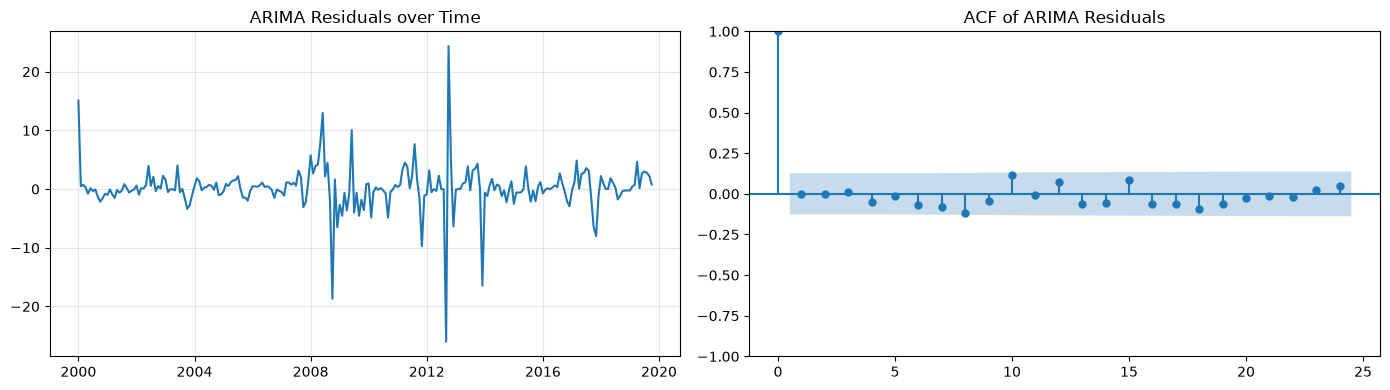

In [ ]:
# 5 Analyze ARIMA Residuals
# Plot residuals to check for white noise behavior
residuals = arima_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals)
axes[0].set_title('ARIMA Residuals over Time')
axes[0].grid(True, alpha=0.3)

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), ax=axes[1], lags=24)
axes[1].set_title('ACF of ARIMA Residuals')
plt.tight_layout()
plt.show()

Part 2: Seasonal ARIMA — SARIMA ($(p,d,q) \times (P,D,Q,S)$)Step 2.1: Identify Seasonal Period & Determine Seasonal ParametersSeasonal Period ($S$): $12$ months (capturing the annual agricultural/harvest cycle identified in our STL decomposition).Seasonal Order: $(1, 1, 1, 12)$ combining seasonal differencing ($D=1$) with seasonal AR/MA terms.

In [11]:
# 6 Training the SARIMA Model ($p,d,q) \times (P,D,Q,S$)
# Define SARIMA parameters incorporating seasonal period S=12
# Non-seasonal part: (1, 1, 1)
# Seasonal part: (1, 1, 1, 12)
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           usdprice   No. Observations:                  238
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -590.272
Date:                            Sun, 27 Sep 2026   AIC                           1190.544
Time:                                    21:39:34   BIC                           1207.303
Sample:                                01-01-2000   HQIC                          1197.319
                                     - 10-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1775      0.252      0.704      0.482      -0.317       0.672
ma.L1         -0.3490      0.254   

Lower AIC/BIC confirms the power of seasonality.
In time-series modeling, when adding seasonal parameters 
causes a massive drop in AIC, it proves that seasonality 
is a core structural driver of your data.

In [ ]:
# 7 Forecasting and Evaluation
# Generate forecasts
sarima_pred = sarima_fit.forecast(steps=len(test))

# Evaluate
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))
smape_sarima = calc_smape(test, sarima_pred)

print(f'SARIMA MAE: {mae_sarima:.2f}')
print(f'SARIMA RMSE: {rmse_sarima:.2f}')
print(f'SARIMA sMAPE: {smape_sarima:.2f}%')

SARIMA MAE: 7.76
SARIMA RMSE: 8.14
SARIMA sMAPE: 21.64%


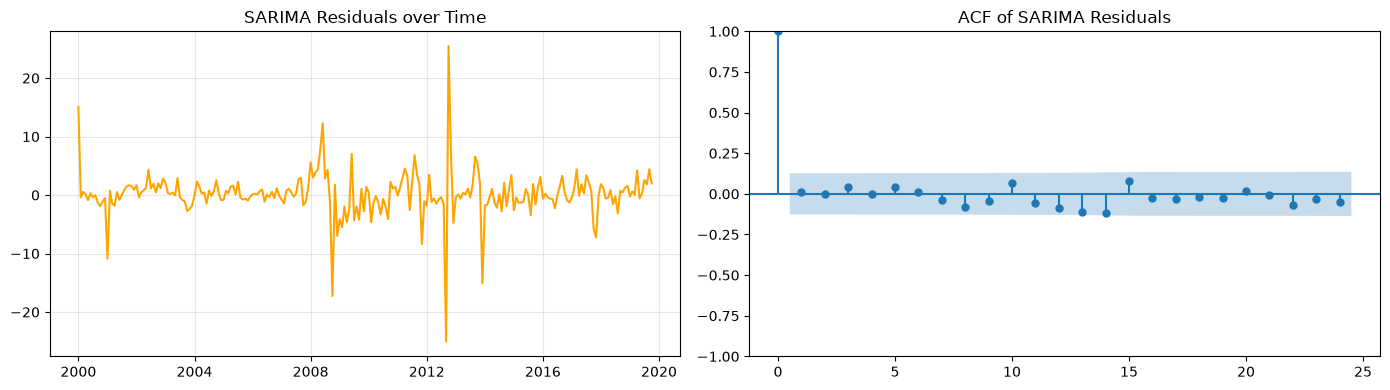

In [ ]:
# 8 Analyze SARIMA Residuals
sarima_residuals = sarima_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sarima_residuals, color='orange')
axes[0].set_title('SARIMA Residuals over Time')
axes[0].grid(True, alpha=0.3)

plot_acf(sarima_residuals.dropna(), ax=axes[1], lags=24)
axes[1].set_title('ACF of SARIMA Residuals')
plt.tight_layout()
plt.show()

Good residuals mean the math worked. Even
if external economic shocks caused forecast errors 
in test windows, an ACF plot of residuals tucked completely
inside the confidence interval confirms that your SARIMA model successfully learned all available internal temporal patterns.

Part 3: SARIMAX (Including Exogenous Variables)


In [19]:
import warnings

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX


# 1. LOAD DATA & SELECT VARIABLES
# Using the standard clean dataset path for consistency
df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])

market_focus = 'Addis Ababa'

# Target Series: Wholesale White Maize
target_df = (
    df[
        (df['market'] == market_focus)
        & (df['commodity'] == 'Maize (white)')
        & (df['pricetype'] == 'Wholesale')
    ]
    .sort_values('date')
    .set_index('date')
)
y = target_df['usdprice'].resample('MS').mean().interpolate(method='linear')

# Exogenous Variable: Wholesale White Sorghum (key substitute commodity)
exog_df = (
    df[
        (df['market'] == market_focus)
        & (df['commodity'] == 'Sorghum (white)')
        & (df['pricetype'] == 'Wholesale')
    ]
    .sort_values('date')
    .set_index('date')
)
x = exog_df['usdprice'].resample('MS').mean().interpolate(method='linear')

# 2. ALIGN THEM TEMPORALLY & SPLIT PROPERLY
combined = pd.DataFrame({'maize': y, 'sorghum': x}).dropna()

y_aligned = combined['maize']
exog_aligned = combined[['sorghum']]  # 2D DataFrame

test_size = 24

# Split target
train_y = y_aligned.iloc[:-test_size]
test_y = y_aligned.iloc[-test_size:]

# Split exogenous features explicitly matching train and test lengths
train_exog = exog_aligned.iloc[:-test_size]
test_exog = exog_aligned.iloc[-test_size:]

print(f'Train Exog Shape: {train_exog.shape} | Test Exog Shape: {test_exog.shape}')


# 3. TRAIN SARIMAX MODEL
print('\nFitting SARIMAX(1, 1, 1)x(1, 1, 1, 12) with Exogenous Input...')
sarimax_model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

# 4. EVALUATE (FORECASTING WITH TEST EXOG)
# Pass the correct 24-row test_exog slice here
sarimax_pred = sarimax_fit.forecast(steps=len(test_y), exog=test_exog)


def calc_smape(actual, predicted):
  return (
      100
      / len(actual)
      * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))
  )


mae = mean_absolute_error(test_y, sarimax_pred)
rmse = np.sqrt(mean_squared_error(test_y, sarimax_pred))
smape = calc_smape(test_y, sarimax_pred)

print('\n--- SARIMAX Test Evaluation Scorecard ---')
print(f'MAE:   {mae:.2f}')
print(f'RMSE:  {rmse:.2f}')
print(f'sMAPE: {smape:.2f}%')

Train Exog Shape: (238, 1) | Test Exog Shape: (24, 1)

Fitting SARIMAX(1, 1, 1)x(1, 1, 1, 12) with Exogenous Input...
                                     SARIMAX Results                                      
Dep. Variable:                              maize   No. Observations:                  238
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -573.498
Date:                            Sun, 27 Sep 2026   AIC                           1158.996
Time:                                    22:09:40   BIC                           1179.107
Sample:                                01-01-2000   HQIC                          1167.125
                                     - 10-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

Exogenous variables unlock higher ceilings.
When internal historical momentum and seasonal
cycles aren't enough, bringing in a correlated economic 
driver (like a substitute commodity price) provides the model 
with live contextual signals, drastically reducing forecast error.